<a href="https://colab.research.google.com/github/paolavaldes0107-netizen/IA/blob/main/IA_act_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Introducción teórica

Un árbol de decisión es un modelo de aprendizaje supervisado que clasifica datos mediante reglas tipo preguntas (condiciones). Cada nodo representa una decisión basada en una característica, y las hojas contienen la clase final.

La profundidad del árbol (max_depth) indica cuántos niveles puede tener el modelo:

Poca profundidad → modelo simple → subajuste (underfitting)

Mucha profundidad → modelo complejo → sobreajuste (overfitting)

El objetivo es encontrar un equilibrio donde el modelo generalice bien.

In [ ]:
import pandas as pd

# Cargar dataset (ajusta la ruta si es necesario)
df = pd.read_csv("mnist_train.csv")

# Mostrar primeras filas
df.head()

,label,data_0,data_1,data_2,data_3,data_4,data_5,data_6,data_7,data_8,...,data_774,data_775,data_776,data_777,data_778,data_779,data_780,data_781,data_782,data_783
0,5,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [ ]:
# Dimensiones
print("Filas:", df.shape[0])
print("Columnas:", df.shape[1])

# Valores nulos
print(df.isnull().sum().sum())

Filas: 55000
Columnas: 785
0


El dataset contiene 55,000 filas y 785 columnas.

Cada fila representa una imagen de un dígito escrito a mano (0–9).

Las columnas están compuestas por:
- 1 columna llamada "label", que indica el dígito real.
- 784 columnas que representan los valores de los píxeles (imágenes de 28x28 convertidas a vector).

No se encontraron valores nulos en el dataset, por lo que no fue necesario realizar limpieza de datos.

Los valores de los píxeles van de 0 a 255, donde 0 representa negro y 255 blanco.

In [ ]:
# y = etiqueta (primer columna)
y = df.iloc[:, 0]

# X = pixeles
X = df.iloc[:, 1:]

# Clases únicas
print("Clases:", y.unique())
print("Cantidad de clases:", len(y.unique()))

Clases: [5 0 4 1 9 2 3 6 7 8]
Cantidad de clases: 10


Cada fila en X representa una imagen convertida en 784 valores de intensidad.

y representa el dígito real (0 al 9).

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Entrenamiento:", X_train.shape[0])
print("Prueba:", X_test.shape[0])

Entrenamiento: 44000
Prueba: 11000


In [ ]:
profundidades = [5, 10, 20]

En datasets como MNIST (muchas variables), probar distintas profundidades es clave porque:

Árbol pequeño → no capta patrones complejos

Árbol muy profundo → memoriza los datos

Comparar permite encontrar el mejor balance

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

resultados = []

for p in profundidades:
    modelo = DecisionTreeClassifier(max_depth=p, random_state=42)

    modelo.fit(X_train, y_train)

    # Predicciones
    y_train_pred = modelo.predict(X_train)
    y_test_pred = modelo.predict(X_test)

    # Accuracy
    acc_train = accuracy_score(y_train, y_train_pred)
    acc_test = accuracy_score(y_test, y_test_pred)

    resultados.append([p, acc_train, acc_test])

resultados

[[5, 0.6549318181818182, 0.6566363636363637],
 [10, 0.9054772727272727, 0.8528181818181818],
 [20, 0.9957954545454546, 0.8647272727272727]]

In [ ]:
tabla = pd.DataFrame(resultados, columns=["Profundidad", "Train", "Test"])
tabla

,Profundidad,Train,Test
0,5,0.654932,0.656636
1,10,0.905477,0.852818
2,20,0.995795,0.864727


La mayor accuracy en prueba se obtiene con profundidad 20 (0.8647), aunque la diferencia con profundidad 10 (0.8528) es pequeña.

En profundidad 5 hay subajuste.

En profundidad 20 hay sobreajuste porque train es mucho mayor que test.

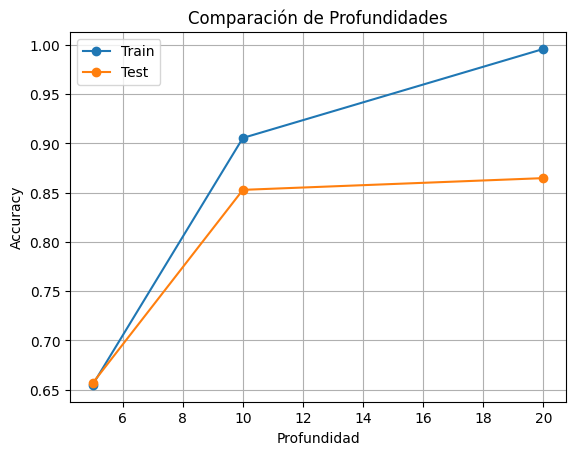

In [ ]:
import matplotlib.pyplot as plt

plt.plot(tabla["Profundidad"], tabla["Train"], marker='o', label="Train")
plt.plot(tabla["Profundidad"], tabla["Test"], marker='o', label="Test")

plt.xlabel("Profundidad")
plt.ylabel("Accuracy")
plt.title("Comparación de Profundidades")
plt.legend()
plt.grid()

plt.show()

Aumentar la profundidad no siempre mejora el modelo.

El sobreajuste comienza en profundidad 20.

La mejor profundidad es 10.

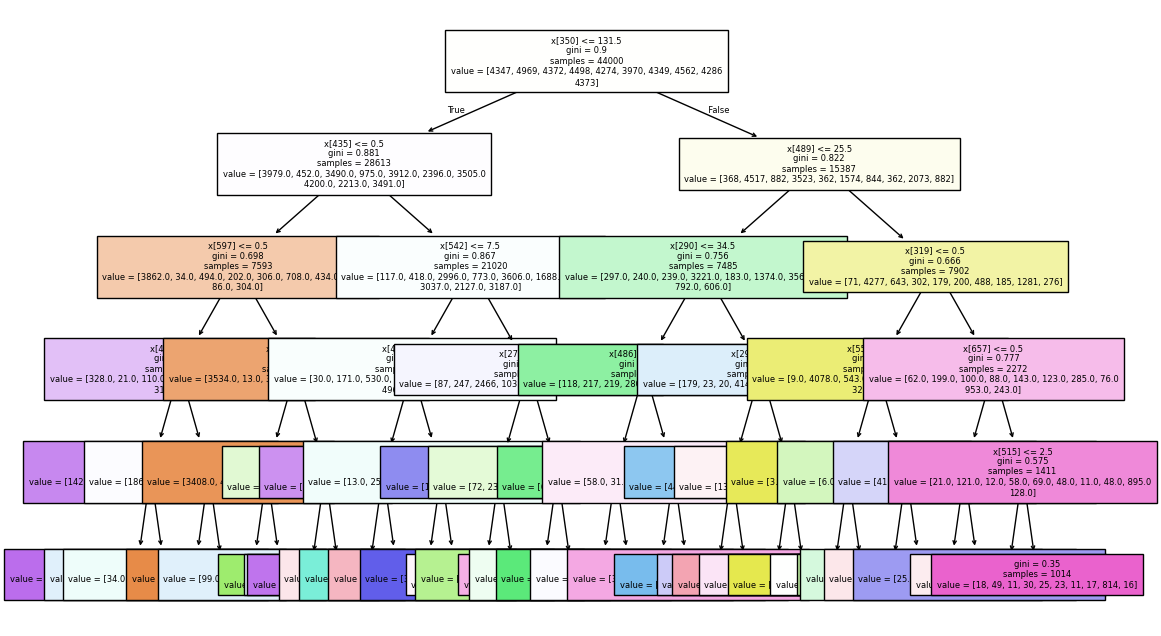

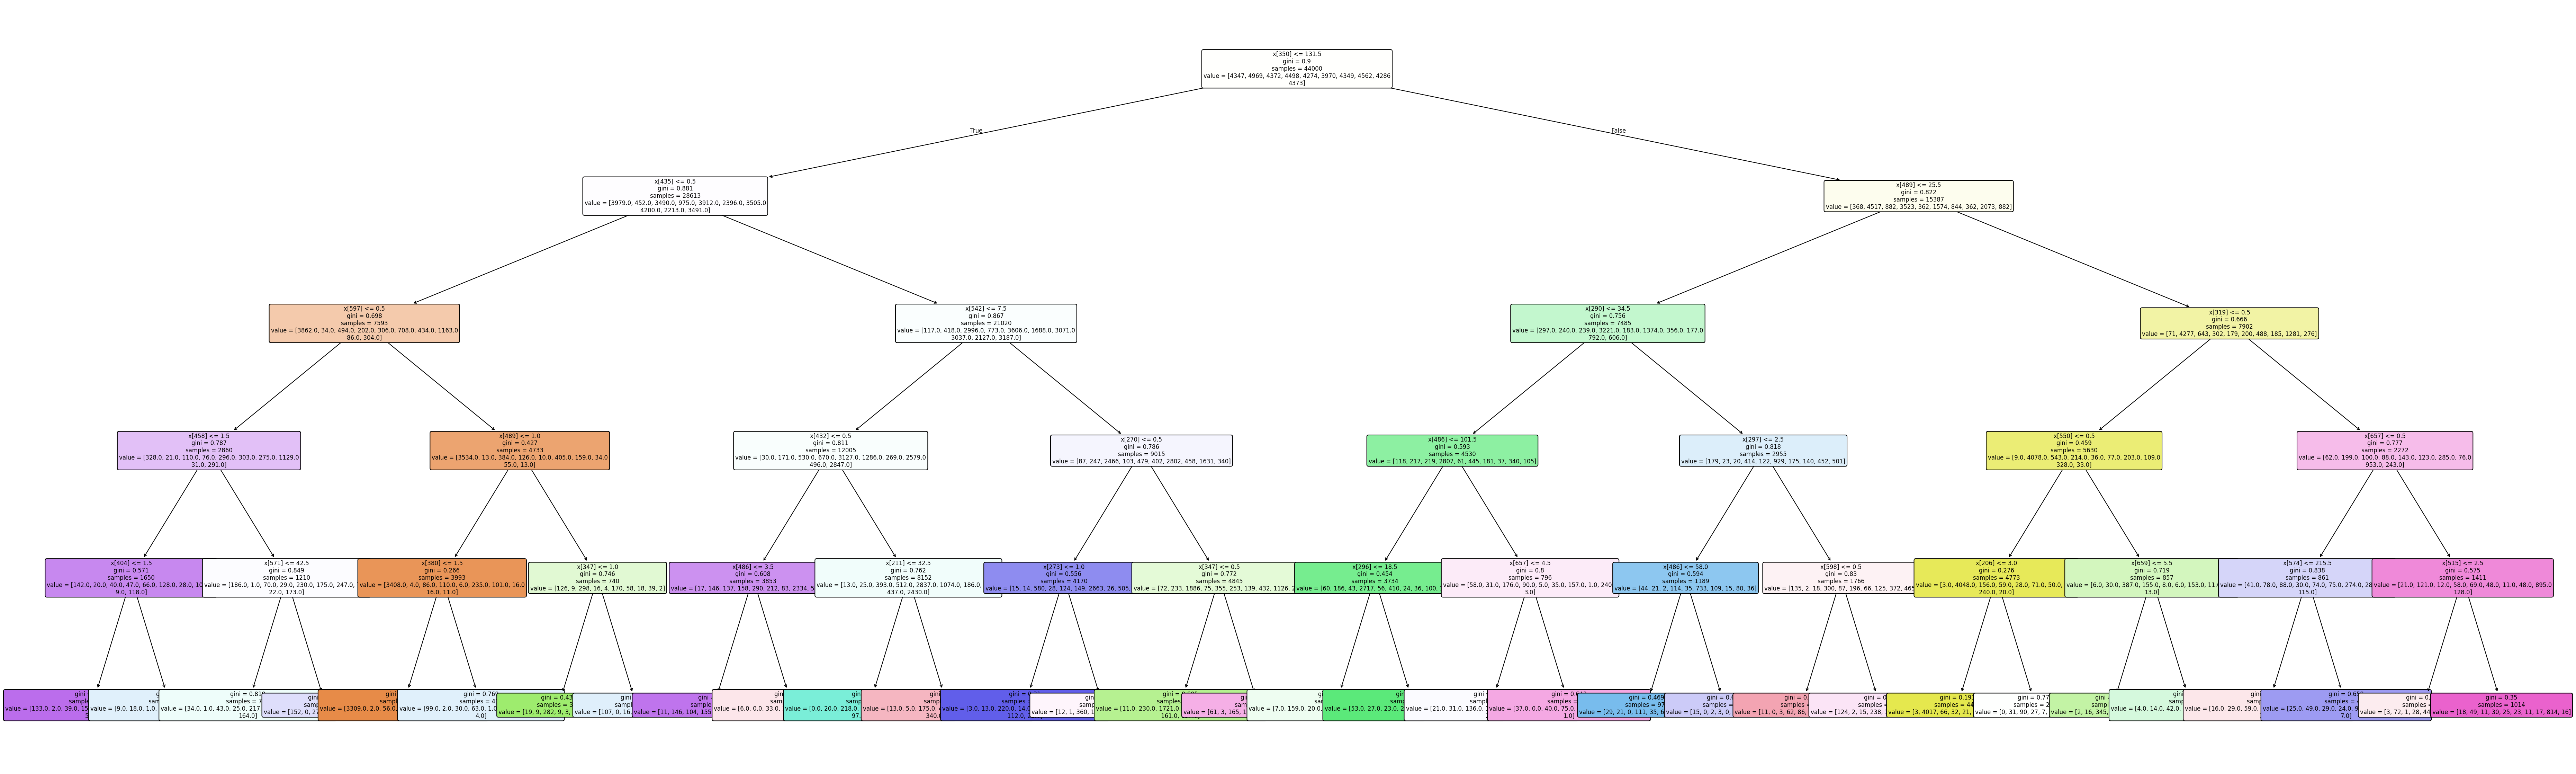

In [ ]:
from sklearn.tree import plot_tree

modelo_simple = DecisionTreeClassifier(max_depth=5, random_state=42)
modelo_simple.fit(X_train, y_train)

plt.figure(figsize=(12,8))
plot_tree(modelo_simple, filled=True, fontsize=6)
plt.show()


plt.figure(figsize=(50,15), dpi=150)

plot_tree(
    modelo_simple,
    filled=True,
    fontsize=8,
    rounded=True
)

plt.tight_layout()
plt.show()

El árbol usa valores de píxeles para tomar decisiones.

Es difícil de interpretar porque hay muchas variables.

#Conclusion
Los árboles de decisión funcionan de manera aceptable en MNIST, pero no son los mejores modelos para este tipo de datos complejos.

La profundidad que ofrece mejor balance suele ser una intermedia (como 10), ya que logra buena precisión sin sobreajustar demasiado.

El modelo con profundidad baja (5) presenta subajuste, porque no logra capturar patrones complejos de las imágenes.

El modelo con profundidad alta (20) tiende a sobreajuste, ya que memoriza los datos de entrenamiento y pierde capacidad de generalización.